<a href="https://colab.research.google.com/github/Krishanu2006/qaoa-qubo/blob/main/bridging_quantum_algorithms_and_classical_finance.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
df = pd.read_csv('nse_derivatives.csv')
n_qubits = 8
data = df.drop(columns=['Month'])
data = data.iloc[:, :n_qubits]
data.head()
returns = data.pct_change().dropna()
mu = returns.mean().values
cov = returns.cov().values
returns.head()

,Index_Future,Stock_Future,Index_Option,Stock_Option
1,0.505469,0.978187,0.208020,-0.165679
2,0.640126,-0.649081,0.018698,0.024470
3,-0.040543,0.151826,-0.051177,0.561707
4,-0.421499,-0.224727,-0.099940,-0.383437
5,0.282052,-0.059683,-0.025408,0.058949


In [3]:
import numpy as np

mu = returns.mean().values
cov = returns.cov().values

print("Expected Returns:", mu)
print("Covariance Matrix:\n", cov)

Expected Returns: [0.07757335 0.26200028 0.27766134 0.75403597]
Covariance Matrix:
 [[ 0.18019388  0.09238377 -0.04176705 -0.13608393]
 [ 0.09238377  0.69498424 -0.26037614  0.05410751]
 [-0.04176705 -0.26037614  2.87391757 -0.0435813 ]
 [-0.13608393  0.05410751 -0.0435813  20.00864738]]


In [4]:
lambdas = [0.1, 0.3, 0.5, 0.7, 1.0]

for lambda_ in lambdas:
    Q = lambda_ * cov - np.diag(mu)

    print(f"\nLambda = {lambda_}")
    print("QUBO Matrix:\n", Q)


Lambda = 0.1
QUBO Matrix:
 [[-0.05955396  0.00923838 -0.00417671 -0.01360839]
 [ 0.00923838 -0.19250185 -0.02603761  0.00541075]
 [-0.00417671 -0.02603761  0.00973042 -0.00435813]
 [-0.01360839  0.00541075 -0.00435813  1.24682877]]

Lambda = 0.3
QUBO Matrix:
 [[-0.02351519  0.02771513 -0.01253012 -0.04082518]
 [ 0.02771513 -0.053505   -0.07811284  0.01623225]
 [-0.01253012 -0.07811284  0.58451393 -0.01307439]
 [-0.04082518  0.01623225 -0.01307439  5.24855824]]

Lambda = 0.5
QUBO Matrix:
 [[ 0.01252359  0.04619189 -0.02088353 -0.06804197]
 [ 0.04619189  0.08549184 -0.13018807  0.02705376]
 [-0.02088353 -0.13018807  1.15929744 -0.02179065]
 [-0.06804197  0.02705376 -0.02179065  9.25028772]]

Lambda = 0.7
QUBO Matrix:
 [[ 0.04856236  0.06466864 -0.02923694 -0.09525875]
 [ 0.06466864  0.22448869 -0.1822633   0.03787526]
 [-0.02923694 -0.1822633   1.73408096 -0.03050691]
 [-0.09525875  0.03787526 -0.03050691 13.2520172 ]]

Lambda = 1.0
QUBO Matrix:
 [[ 0.10262053  0.09238377 -0.04176705 -0

In [5]:
import numpy as np
import itertools

n = len(mu)

best_cost = float('inf')
best_portfolio = None

results = []

for x in itertools.product([0, 1], repeat=n):
    x = np.array(x)

    # Skip empty portfolio
    if np.sum(x) == 0:
        continue

    # QUBO cost
    cost = x @ Q @ x

    # Portfolio return
    ret = x @ mu

    # Portfolio risk
    risk = x @ cov @ x

    # Sharpe ratio (basic version)
    sharpe = ret / (np.sqrt(risk) + 1e-8)

    results.append((x, cost, ret, risk, sharpe))

    # Track best (minimum cost)
    if cost < best_cost:
        best_cost = cost
        best_portfolio = x

# Sort results (optional, for analysis)
results = sorted(results, key=lambda x: x[1])

print("Best Portfolio (Binary):", best_portfolio)
print("Minimum Cost:", best_cost)

# Show top 5 portfolios
print("\nTop 5 Portfolios:")
for r in results[:5]:
    print(f"Portfolio: {r[0]}, Cost: {r[1]:.4f}, Return: {r[2]:.4f}, Risk: {r[3]:.4f}, Sharpe: {r[4]:.4f}")

Best Portfolio (Binary): [1 0 0 0]
Minimum Cost: 0.10262052704303407

Top 5 Portfolios:
Portfolio: [1 0 0 0], Cost: 0.1026, Return: 0.0776, Risk: 0.1802, Sharpe: 0.1827
Portfolio: [0 1 0 0], Cost: 0.4330, Return: 0.2620, Risk: 0.6950, Sharpe: 0.3143
Portfolio: [1 1 0 0], Cost: 0.7204, Return: 0.3396, Risk: 1.0599, Sharpe: 0.3298
Portfolio: [0 1 1 0], Cost: 2.5085, Return: 0.5397, Risk: 3.0481, Sharpe: 0.3091
Portfolio: [0 0 1 0], Cost: 2.5963, Return: 0.2777, Risk: 2.8739, Sharpe: 0.1638


In [6]:
import numpy as np

def portfolio_metrics(weights, mu, cov):

    # Convert to NumPy arrays (IMPORTANT)
    weights = np.array(weights, dtype=float)
    mu = np.array(mu, dtype=float)
    cov = np.array(cov, dtype=float)

    # Return
    ret = np.dot(weights, mu)

    # Risk (variance)
    risk = np.dot(weights, np.dot(cov, weights))

    # Volatility
    vol = np.sqrt(risk)

    # Sharpe ratio
    sharpe = ret / (vol + 1e-8)

    return float(ret), float(risk), float(vol), float(sharpe)

In [7]:
x = np.array([1, 0, 0, 0])  # sample portfolio

ret, risk, vol, sharpe = portfolio_metrics(x, mu, cov)

print("Return:", ret)
print("Risk:", risk)
print("Volatility:", vol)
print("Sharpe Ratio:", sharpe)

Return: 0.07757335187051448
Risk: 0.18019387891354854
Volatility: 0.42449249570934533
Sharpe Ratio: 0.18274374889348413


In [9]:
!pip install pennylane

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 49.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 937.5/937.5 kB 43.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.5/25.5 MB 58.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 65.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.2/167.2 kB 14.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 78.3 MB/s eta 0:00:00


In [10]:
import numpy as np
import pennylane as qml

def qubo_to_hamiltonian(Q):
    """
    Convert QUBO matrix to PennyLane Hamiltonian.

    Args:
        Q (np.ndarray): NxN QUBO matrix

    Returns:
        qml.Hamiltonian: Cost Hamiltonian
    """
    n = Q.shape[0]

    coeffs = []
    observables = []

    constant = 0.0

    for i in range(n):
        for j in range(i,n):
            if Q[i, j] == 0:
                continue

            if i == j:
                # Diagonal term: x_i^2 = x_i
                constant += Q[i, i] / 2
                coeffs.append(-Q[i, i] / 2)
                observables.append(qml.PauliZ(i))
            else:
                # Off-diagonal term
                constant += Q[i, j] / 4

                # Z_i term
                coeffs.append(-Q[i, j] / 4)
                observables.append(qml.PauliZ(i))

                # Z_j term
                coeffs.append(-Q[i, j] / 4)
                observables.append(qml.PauliZ(j))

                # Z_i Z_j term
                coeffs.append(Q[i, j] / 4)
                observables.append(qml.PauliZ(i) @ qml.PauliZ(j))

    H = qml.Hamiltonian(coeffs, observables)

    return H, constant

In [11]:
H, constant = qubo_to_hamiltonian(Q)

print("Hamiltonian:")
print(H)

print("Constant term:", constant)

Hamiltonian:
-0.05131026352151703 * Z(0) + -0.02309594345169857 * Z(0) + -0.02309594345169857 * Z(1) + 0.02309594345169857 * (Z(0) @ Z(1)) + 0.010441763095783723 * Z(0) + 0.010441763095783723 * Z(2) + -0.010441763095783723 * (Z(0) @ Z(2)) + 0.03402098342379694 * Z(0) + 0.03402098342379694 * Z(3) + -0.03402098342379694 * (Z(0) @ Z(3)) + -0.2164919827602684 * Z(1) + 0.06509403464717212 * Z(1) + 0.06509403464717212 * Z(2) + -0.06509403464717212 * (Z(1) @ Z(2)) + -0.013526878259190559 * Z(1) + -0.013526878259190559 * Z(3) + 0.013526878259190559 * (Z(1) @ Z(3)) + -1.2981281139125151 * Z(2) + 0.01089532504460864 * Z(2) + 0.01089532504460864 * Z(3) + -0.01089532504460864 * (Z(2) @ Z(3)) + -9.62730570498423 * Z(3)
Constant term: 11.109406780678059


In [12]:
import pennylane as qml
import numpy as np

n_qubits = 8
data = data.iloc[:, :n_qubits]
dev = qml.device("default.qubit", wires=n_qubits)

@qml.qnode(dev)
def cost_circuit(params, H_cost):
    p = len(params) // 2
    gammas = params[:p]
    betas = params[p:]

    # 1. Initial superposition
    for i in range(n_qubits):
        qml.Hadamard(wires=i)

    # 2. QAOA layers
    for layer in range(p):
        # Cost unitary
        qml.ApproxTimeEvolution(H_cost, gammas[layer], 1)

        # Mixer unitary
        for i in range(n_qubits):
            qml.RX(2 * betas[layer], wires=i)

    # 3. Expectation value
    return qml.expval(H_cost)

In [13]:
import pennylane as qml
from pennylane import numpy as np

# Number of QAOA layers
p = 1

# Initialize parameters (gamma + beta)
params = np.random.rand(2 * p)

opt = qml.AdamOptimizer(stepsize=0.1)

# Training loop
for i in range(30):
    params = np.random.uniform(0, 2*np.pi, 2 * p)

    if i % 10 == 0:
        print(f"Step {i}: Cost = {cost_circuit(params, H)}")

print("Optimized Parameters:", params)

Step 0: Cost = -6.909420309890919
Step 10: Cost = -4.273585447388833
Step 20: Cost = -1.3380851597831758
Optimized Parameters: [2.88953591 6.13220571]


In [14]:
dev = qml.device("default.qubit", wires=n_qubits, shots=500)

@qml.qnode(dev)
def sample_circuit(params):
    p = len(params) // 2
    gammas = params[:p]
    betas = params[p:]

    # Initial superposition
    for i in range(n_qubits):
        qml.Hadamard(wires=i)

    # QAOA layers
    for layer in range(p):
        qml.ApproxTimeEvolution(H, gammas[layer], 1)

        for i in range(n_qubits):
            qml.RX(2 * betas[layer], wires=i)

    return qml.sample(wires=range(n_qubits))

/usr/local/lib/python3.12/dist-packages/pennylane/devices/device_api.py:207: PennyLaneDeprecationWarning: Setting shots on device is deprecated. Please use the `set_shots` transform on the respective QNode instead.
  warnings.warn(


In [15]:
dev = qml.device("default.qubit", wires=n_qubits, shots=1000)

In [16]:
dev = qml.device("default.qubit", wires=n_qubits, shots=5000)
samples = sample_circuit(params)

In [17]:
from collections import Counter

samples_list = [tuple(s) for s in samples]
counts = Counter(samples_list)

best_tuple, freq = counts.most_common(1)[0]

best_sample = np.array(best_tuple)

print("Best Portfolio:", best_sample)
print("Frequency:", freq)

Best Portfolio: [1 0 1 1 0 0 0 0]
Frequency: 7


In [18]:
from collections import Counter

samples_list = [tuple(s) for s in samples]
counts = Counter(samples_list)

best_sample = np.array(counts.most_common(1)[0][0])

print("Quantum Best Portfolio:", best_sample)

Quantum Best Portfolio: [1 0 1 1 0 0 0 0]


In [19]:
print("Classical:", best_portfolio)
print("Quantum:", best_sample[0])

Classical: [1 0 0 0]
Quantum: 1


In [20]:
print(mu.shape)   # (8,)
print(cov.shape)  # (8,8)

(4,)
(4, 4)


In [21]:
n_qubits = len(mu)

dev = qml.device("default.qubit", wires=n_qubits)

best_sample = np.array(best_sample, dtype=float).flatten()

# Critical check
print("weights shape:", best_sample.shape)
print("mu shape:", mu.shape)

# Fix mismatch if needed
if len(best_sample) != len(mu):
    print("Fixing mismatch...")
    best_sample = best_sample[:len(mu)]

ret, risk, vol, sharpe = portfolio_metrics(best_sample, mu, cov)

print("Return:", ret)
print("Risk:", risk)
print("Volatility:", vol)
print("Sharpe:", sharpe)

weights shape: (8,)
mu shape: (4,)
Fixing mismatch...
Return: 1.109270664990958
Risk: 22.61989425731397
Volatility: 4.756037663571849
Sharpe: 0.23323420484133395


In [22]:
c_ret, c_risk, c_vol, c_sharpe = portfolio_metrics(best_portfolio, mu, cov)

q_ret, q_risk, q_vol, q_sharpe = portfolio_metrics(
    np.array(best_sample), mu, cov
)

print("\nClassical -> Return:", c_ret, "Risk:", c_risk, "Sharpe:", c_sharpe)
print("Quantum   -> Return:", q_ret, "Risk:", q_risk, "Sharpe:", q_sharpe)


Classical -> Return: 0.07757335187051448 Risk: 0.18019387891354854 Sharpe: 0.18274374889348413
Quantum   -> Return: 1.109270664990958 Risk: 22.61989425731397 Sharpe: 0.23323420484133395


In [23]:
results_summary = []
q_ret, q_risk, q_vol, q_sharpe = portfolio_metrics(
    np.array(best_sample), mu, cov
)

results_summary.append({
    "lambda": lambda_,
    "portfolio": best_sample,
    "return": q_ret,
    "risk": q_risk,
    "sharpe": q_sharpe
})

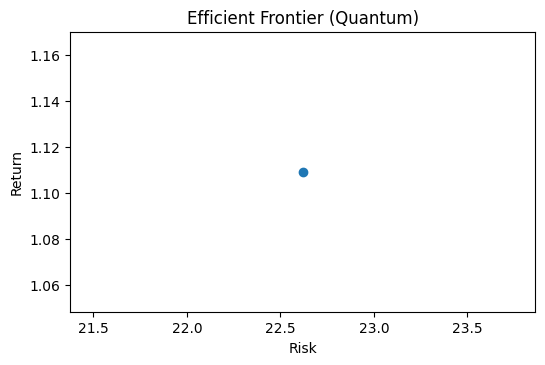

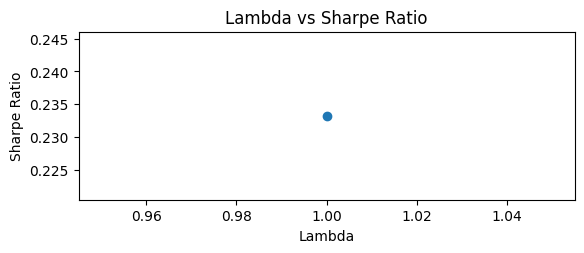

In [24]:
import matplotlib.pyplot as plt
risks = [r["risk"] for r in results_summary]
returns = [r["return"] for r in results_summary]
sharpes = [r["sharpe"] for r in results_summary]
lams = [r["lambda"] for r in results_summary]

plt.figure(figsize=(6,8))
plt.subplot(2, 1, 1)
plt.scatter(risks, returns)
plt.xlabel("Risk")
plt.ylabel("Return")
plt.title("Efficient Frontier (Quantum)")
plt.show()

plt.subplot(2, 1, 2)
plt.plot(lams, sharpes, marker='o')
plt.xlabel("Lambda")
plt.ylabel("Sharpe Ratio")
plt.title("Lambda vs Sharpe Ratio")
plt.show()

In [25]:
print("\n===== FINAL SUMMARY =====")
for r in results_summary:
    print(r)


===== FINAL SUMMARY =====
{'lambda': 1.0, 'portfolio': tensor([1., 0., 1., 1.], requires_grad=True), 'return': 1.109270664990958, 'risk': 22.61989425731397, 'sharpe': 0.23323420484133395}


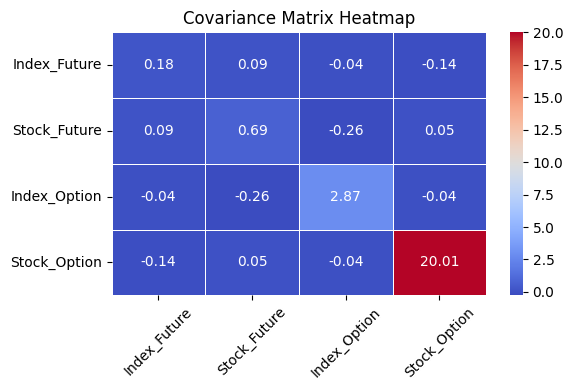

In [26]:
import seaborn as sns
import matplotlib.pyplot as plt

# Ensure correct DataFrame
returns_df = data.pct_change().dropna()

cov_matrix = returns_df.cov()

plt.figure(figsize=(6,4))

sns.heatmap(
    cov_matrix,
    annot=True,        # shows values
    fmt=".2f",         # 2 decimal places
    cmap="coolwarm",   # better color contrast
    linewidths=0.5
)

plt.title("Covariance Matrix Heatmap")
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

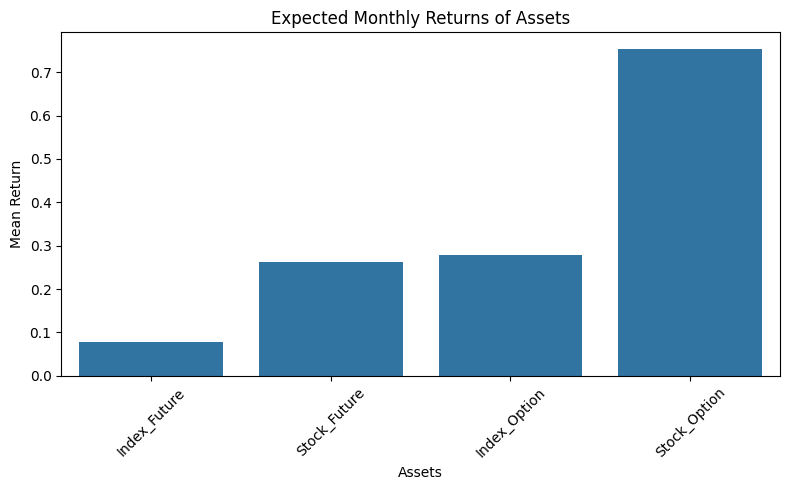

In [27]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Ensure returns DataFrame exists
returns_df = data.pct_change().dropna()

# Expected returns
mu = returns_df.mean()

# Convert to DataFrame for plotting
mu_df = pd.DataFrame({
    "Asset": mu.index,
    "Expected Return": mu.values
})

plt.figure(figsize=(8,5))

sns.barplot(
    x="Asset",
    y="Expected Return",
    data=mu_df
)

plt.title("Expected Monthly Returns of Assets")
plt.xticks(rotation=45)
plt.ylabel("Mean Return")
plt.xlabel("Assets")
plt.tight_layout()

plt.show()

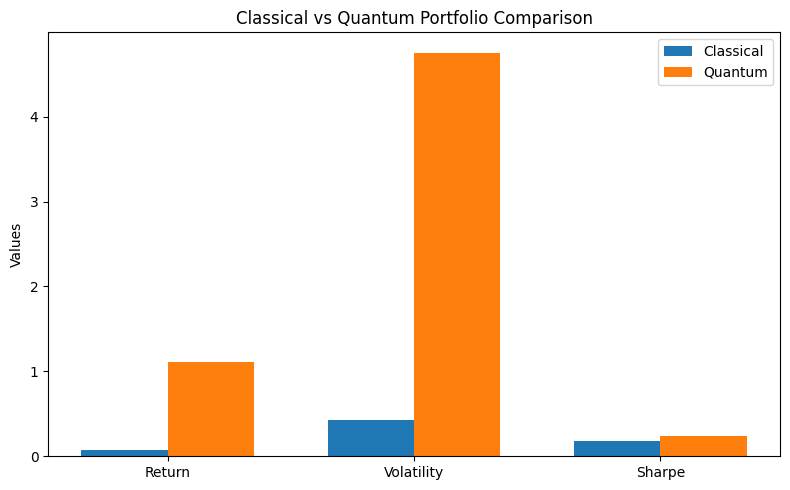

In [28]:
import matplotlib.pyplot as plt
import numpy as np

labels = ['Return', 'Volatility', 'Sharpe']

classical_values = [c_ret, c_vol, c_sharpe]
quantum_values = [q_ret, q_vol, q_sharpe]

x = np.arange(len(labels))
width = 0.35

plt.figure(figsize=(8,5))

plt.bar(x - width/2, classical_values, width, label='Classical')
plt.bar(x + width/2, quantum_values, width, label='Quantum')

plt.xticks(x, labels)
plt.title("Classical vs Quantum Portfolio Comparison")
plt.ylabel("Values")
plt.legend()

plt.tight_layout()
plt.show()